In [ ]:
### STEP 1:IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
import re
from PIL import Image


os.chdir("W:/Project/MPI_Registration/Proj_Spatial_Registration/")

# Diretórios de saída
out_dir = 'results/py_output/'
r_dir   = 'results/r_output/'
desi_dir = 'results/desi_output/'


# Número de features que pretende usar (ajuste conforme o experimento)
n_features = 16

### Reference landmarks refer to Visium landmarks
### Query landmarks refer to DESI landmarks

# Read images and landmarks
# === Carrega os landmarks do Visium ===
query_landmarks = pd.read_csv(r_dir + 'Query_Reference_Landmarks_for_Visium_Data.csv', index_col=[0, 1])

# Conversão de nomes para compatibilizar com DESI
convert_ids = pd.read_csv(r_dir + "convert_IDs.csv")

# Merge IDs
#query_landmarks = pd.merge(query_landmarks, convert_ids, on='sample_ID', how='left')
query_landmarks = pd.merge(query_landmarks, convert_ids, on='sample_ID', how='left')
query_landmarks = query_landmarks.sort_values(['desi','Coordinates'])


# Lista de amostras e imagens
paths = query_landmarks.sample_ID.unique().tolist()
samples = query_landmarks.desi.unique().tolist()

# === Lê imagens referentes ao Visium ===
#query_images = [cv2.imread(os.path.join(out_dir, path + "_hires_region.png")) for path in paths]
query_images = [cv2.imread(os.path.join('W:/Project/MPI_Registration/Proj_Spatial_Registration/results/plots', path + "_hires_image.png")) for path in paths]


# === Lê arquivos do diretório DESI ===
arr = os.listdir(desi_dir)
reference_files = [file for file in arr if re.search("pos|neg1|neg2",file)]

# === Lê os landmarks de referência do DESI ===
reference_landmarks = pd.read_csv(os.path.join(r_dir, 'Query_Reference_Landmarks_for_DESI_Data.csv'), index_col=[0, 1])
reference_landmarks = reference_landmarks.sort_values(["sample_ID","charge"])

# Função auxiliar para listar apenas itens únicos (sem repetição)
# Prin t unique image files of DESI Data
from functools import reduce
def unique(list1): 
    # Print directly by using * symbol
    ans = reduce(lambda re, x: re+[x] if x not in re else re, list1, [])
    return(ans)

#print(unique(reference_landmarks.image_file))
#print(unique(query_landmarks.image_file))

print(unique(reference_landmarks.image_file))
print(unique(query_landmarks.image_file))

['5a1_ABCA7_neg1_to_image_3.png', '5a1_ABCA7_pos_to_image_4.png', '5a3_BIN1_neg2_to_image_3.png', '5a3_BIN1_pos_to_image_4.png']
['ABCA7-5-a1-7_hires_image.png', 'BIN1-5-a3-8_hires_image.png']


In [198]:
reference_landmarks.head()

,,Coordinates,sample_ID,charge,image_file,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
,Sample,,,,,,,,,,,,,,,,,,,,
3Q_X,3,X,5a1_ABCA7,neg1,5a1_ABCA7_neg1_to_image_3.png,179.502347,192.571193,300.258487,342.601549,269.938763,229.163963,172.706546,123.567684,97.952745,10.130098,66.064760,167.479008,178.979593,255.824409,178.456839,93.247961
3Q_Y,3,Y,5a1_ABCA7,neg1,5a1_ABCA7_neg1_to_image_3.png,42.320308,36.047262,65.321478,145.825571,229.466188,211.169803,236.261988,204.374003,218.488357,139.029771,61.662201,35.001754,77.344816,90.413663,93.550186,93.550186
1Q_X,1,X,5a1_ABCA7,pos,5a1_ABCA7_pos_to_image_4.png,202.278313,222.904628,334.398223,373.978450,269.731938,242.416007,177.192254,123.675328,87.439910,12.739201,82.422698,191.128953,192.243889,267.502066,190.571485,101.376609
1Q_Y,1,Y,5a1_ABCA7,pos,5a1_ABCA7_pos_to_image_4.png,66.838689,57.361734,106.418916,181.119624,258.607673,236.866422,254.705397,231.849210,248.015782,154.361161,64.608817,52.344522,95.827024,122.585487,124.815359,115.895871
4Q_X,4,X,5a3_BIN1,neg2,5a3_BIN1_neg2_to_image_3.png,197.044648,213.060111,301.920098,346.350091,324.135095,245.091036,190.845114,144.348609,110.767800,26.040836,103.018383,182.062441,195.494765,276.088706,194.461509,114.900823


In [199]:
query_landmarks.head()

,Coordinates,sample_ID,image_file,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,desi
0,X,ABCA7-5-a1-7,ABCA7-5-a1-7_hires_image.png,1695.120898,1780.885202,2827.209712,3178.843359,2578.493230,2222.571368,1733.714835,1227.705441,910.377516,275.721666,601.626022,1527.880506,1712.273759,2389.811761,1707.985544,1034.735757,5a1_ABCA7
1,Y,ABCA7-5-a1-7,ABCA7-5-a1-7_hires_image.png,292.098634,180.605039,446.474381,1291.252776,1947.349702,1780.109309,1994.520069,1762.956448,1964.502563,1145.453459,527.950470,202.046114,600.850128,592.273698,725.208369,695.190863,5a1_ABCA7
2,X,BIN1-5-a3-8,BIN1-5-a3-8_hires_image.png,1602.888385,1749.986418,2755.156314,2889.996178,2644.832789,1982.891638,1594.716272,1104.389494,597.718489,344.382987,536.427642,1508.909086,1590.630215,2040.096429,1566.113876,973.635686,5a3_BIN1
3,Y,BIN1-5-a3-8,BIN1-5-a3-8_hires_image.png,155.770147,78.135073,470.396496,1316.210189,1782.020628,1651.266820,1843.311475,1569.545691,1782.020628,977.067500,298.782124,86.307186,470.396496,539.859456,650.182981,494.912835,5a3_BIN1


In [200]:
reference_landmarks.sample_ID.unique().tolist()

['5a1_ABCA7', '5a3_BIN1']

In [201]:
paths

['ABCA7-5-a1-7', 'BIN1-5-a3-8']

In [202]:
print(query_landmarks['sample_ID'].unique())
print(reference_landmarks['sample_ID'].unique())


['ABCA7-5-a1-7' 'BIN1-5-a3-8']
['5a1_ABCA7' '5a3_BIN1']


In [203]:
# Functions that perform the alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    # keep only coordinate columns
    
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # want reference coords to have full complement
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1])

    # keep only shared landmarks
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    return cv2.findHomography(query_coords, reference_coords, method = 0)[0], (reference_coords, query_coords)
 

def transform_points(points, mat):
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)

# Function for dealing with image dimension syntax
def Reverse(tuples):
    new_tup = tuples[::-1]
    return new_tup

In [204]:
#  IMPORTANT: SELECT THE IONIZATION MODE BELOW (neg1, neg2, or pos)
# ---------------------------------------------------------------
# Set the 'sign' variable to match the DESI ionization mode you want to process.
# This setting controls which reference landmarks and images will be aligned.
# You MUST re-run all subsequent cells each time you change this value.
# ---------------------------------------------------------------


#sign = 'neg1' # change between 'neg' and 'pos' then re-run bottom part
#sign = 'neg2' # change between 'neg' and 'pos' then re-run bottom part
sign = 'pos' # change between 'neg' and 'pos' then re-run bottom part


In [ ]:
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@



In [205]:
# STEP 2 - Image alignment and transformations

# Read DESI images
reference_images = [cv2.imread(os.path.join(r_dir, file)) for file in unique(reference_landmarks[reference_landmarks.charge.str.contains(sign,regex=True)].image_file)]


#Find the best transformation between Visium and DESI using landmarks 
temp = [calculate_homography_matrix(query_coords = query_landmarks.iloc[(2*i):(2*i+2),:],
                                    reference_coords=reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].iloc[(2*i):(2*i+2),:]) 
        for i in list(range(len(reference_images)))]

mats, coord_sets = zip(*temp)

# Transform Visium images + landmarks into DESI space
images_transformed = [cv2.warpPerspective(src=query_images[i],
                                          M=mats[i],
                                          dsize=tuple([reference_images[i].shape[0],reference_images[i].shape[1]])[::-1]) 
                      for i in range(len(reference_images))]

landmarks_transformed = [transform_points(landmark, mat) for (_, landmark), mat in zip(coord_sets, mats)]



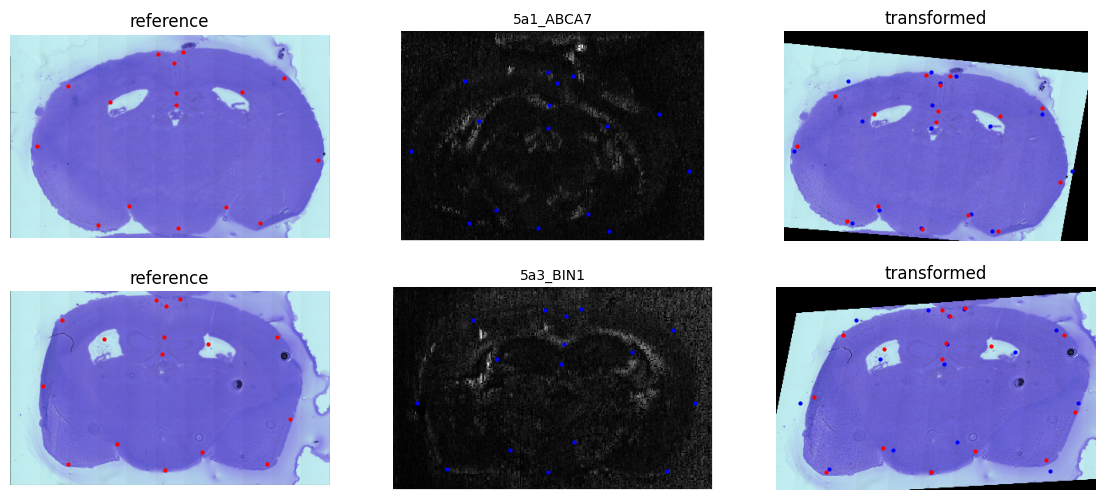

In [206]:
# STEP 3-  Plot images and landmarks, Visium, DESI, and transformed images + landmarks

nrow=2
import re
# plt.figure(figsize=(8, nrow*3))
plt.figure(figsize=(14,nrow*3))
for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed, ref_image) in enumerate(zip(samples,
                                                                                                               coord_sets, landmarks_transformed, reference_images,
                                                                                                                          images_transformed,query_images)):
    
    plt.subplot(nrow,3,3*i+1)
    plt.title('reference')
    plt.imshow(ref_image)
    plt.plot(query_landmarks.filter(regex='V').iloc[(2*i),:].values,
         query_landmarks.filter(regex='V').iloc[(2*i+1),:].values,'ro',markersize=2)
    plt.axis('off')

    # image to transform
    plt.subplot(nrow,3,3*i+2)
    plt.title(re.sub("","",sample), fontsize=10)
    plt.imshow(img)
    plt.plot(reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i),:].values,
         reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i+1),:].values,'bo',markersize=2)
    plt.axis('off')

    # transformed image
    plt.subplot(nrow,3,3*i+3)
    plt.title('transformed')
    plt.imshow(img_transformed)
    plt.plot(reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i),:].values,
        reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i+1),:].values,'bo',markersize=2)
    # plt.plot(query_landmarks.iloc[(2*i),1:n_features].values,query_landmarks.iloc[(2*i+1),1:n_features].values,'ro',markersize=2)
    plt.plot(pd.DataFrame(landmark_transformed).iloc[:,0],
             pd.DataFrame(landmark_transformed).iloc[:,1],'o',c="red",markersize=2)
    plt.axis('off')
    

#plt.savefig('DESI/DESI2/'+'Transformation_'+sign+'_V2.pdf', dpi =400)

In [207]:
# STEP 4 - Link each spot to a pixel in DESI space

# Load in spots and their coordinates
spots_coords = pd.read_csv('results/r_output/spots_coords_hi_res.csv')
spots_coords['imagerow'] = round(spots_coords['imagerow'])
spots_coords['imagecol'] = round(spots_coords['imagecol'])
spots_coords[["imagerow", "imagecol"]] = spots_coords[["imagerow", "imagecol"]].astype("int")
spots_coords.imagerow = spots_coords.imagerow / 1.0
spots_coords.imagecol = spots_coords.imagecol / 1.0

# Transform point into another space (in this case DESI image space)
def transform_row(list_input, mat):
    res = transform_points(np.array(list_input), mat)
    if len(res[0]) == 2:
        return (res[0][0], res[0][1])
    else:
        return (0, 0)

sorter = unique(query_landmarks.sample_ID)
print(sorter)
spots_coords["transformed_row"] = 1.0
spots_coords['transformed_col'] = 1.0

# For each spot's center coordinates, find its linked DESI pixel coordinates
for i in range(spots_coords.shape[0]):
    j = sorter.index(spots_coords.slice[i])
    name = sorter[j]
    mat = mats[j]
    res1, res2 = transform_row(list(spots_coords.loc[i, ['imagecol', 'imagerow']]), mat)
    spots_coords.loc[i, 'transformed_col'] = res1
    spots_coords.loc[i, 'transformed_row'] = res2

# Save result
spots_coords.to_csv('results/py_output/spots_coords_ion_pixels_' + sign + '.csv', index=False)



['ABCA7-5-a1-7', 'BIN1-5-a3-8']
